# Notebook 01 - Linear Regression Model

This notebook follows the [Linear Regression from Scratch in Python](https://www.youtube.com/watch?v=VmbA0pi2cRQ) video. 
<br>Data is sourced from Kaggle.

## 1. Package and data import

In [1]:
# Package import
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

# Download latest version of data from Kaggle API
kagglehub.dataset_download("nikhil7280/student-performance-multiple-linear-regression", output_dir='./data')

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'./data'

In [2]:
# Import data into Juputer file
df = pd.read_csv('data/Student_Performance.csv')
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


## 2. Defining variables and functions

## 2.1 Defining variables

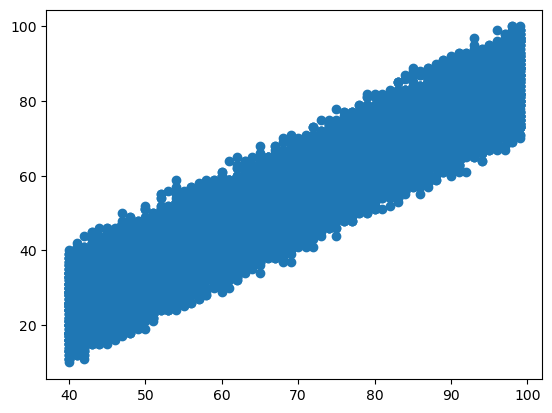

In [3]:
# Variables of interest: 
performance_index = df['Performance Index']
prev_scores = df['Previous Scores']

points = df[['Previous Scores', 'Performance Index']]
# plt.scatter(hours_studied, performance_index)
# plt.scatter(sleep_hours, performance_index)

plt.scatter(prev_scores, performance_index)

## 2.2 Defining functions

In [14]:
# Loss function
def loss_function(m, b, points):
    total_error = 0
    for i in range(len(points)):
        x = points['Performance Index'].iloc[i]
        y = points['Previous Scores'].iloc[i]
        total_error += (y - (m * x + b))**2
    total_error = total_error / float(len(points))
    return total_error

# Gradient descent function
def gradient_descent(m_now, b_now, points, L):
    m_gradient = 0
    b_gradient = 0

    n = len(points)

    for i in range(n):
        x = points["Performance Index"].iloc[i]
        y = points['Previous Scores'].iloc[i]

        m_gradient =+ -(2/n) * x * (y - (m_now*x + b_now))
        b_gradient =+ -(2/n) * (y - (m_now*x + b_now))

    # New m value is the difference between the current m and the m_gradient multiplied by a learning rate
    m = m_now - m_gradient * L
    b = b_now - b_gradient * L

    return m, b

# 3. Applying regression functions

In [15]:
print(df.describe())

       Hours Studied  Previous Scores   Sleep Hours  \
count   10000.000000     10000.000000  10000.000000   
mean        4.992900        69.445700      6.530600   
std         2.589309        17.343152      1.695863   
min         1.000000        40.000000      4.000000   
25%         3.000000        54.000000      5.000000   
50%         5.000000        69.000000      7.000000   
75%         7.000000        85.000000      8.000000   
max         9.000000        99.000000      9.000000   

       Sample Question Papers Practiced  Performance Index  
count                      10000.000000       10000.000000  
mean                           4.583300          55.224800  
std                            2.867348          19.212558  
min                            0.000000          10.000000  
25%                            2.000000          40.000000  
50%                            5.000000          55.000000  
75%                            7.000000          71.000000  
max             

In [ ]:
# Defining starting and iteration values

m = 0
b = 0
L = 0.005   #'step' size
epochs = 800   #number of iterations

# best so far: L = 0.005, epochs = 300

for i in range(epochs):
    if i % 50 == 0:
        print(f'epoch: {i}')
    m, b = gradient_descent(m, b, points, L)

error = loss_function(m, b, points)

print("m:", round(m, 3), "b:", round(b, 3))
print("error:", error)

plt.scatter(prev_scores, performance_index)
plt.plot(list(range(40, 99)), [m * x + b for x in range(40, 99)], color='red')

epoch: 0
epoch: 50
epoch: 100
epoch: 150
